In [1]:
!pip install yfinance requests -q

### IMPORTS

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### FUNCTIONS

In [31]:
def relevance_score(description):
    if not isinstance(description, str) or description == '':
        return 0
    description_lower = description.lower()
    matches = sum(1 for kw in keywords if kw in description_lower)
    return round(matches / len(keywords) * 100, 2)

In [33]:
def apply_cap(weights, cap=0.10):
    weights = weights.copy()
    max_iter = 100
    for _ in range(max_iter):
        over = weights > cap
        if not over.any():
            break
        excess = (weights[over] - cap).sum()
        weights[over] = cap
        under = ~over
        if under.any():
            weights[under] += excess * (weights[under] / weights[under].sum())
    return weights

### PARAMETERS

In [5]:
# Clean energy themed tickers - S&P 500 and global clean energy companies
tickers = [
            'ENPH', 'FSLR', 'SEDG', 'RUN', 'SPWR',             # Solar
            'NEE', 'BEP', 'CWEN', 'AES', 'ED',                 # Wind/Utilities
            'PLUG', 'BE', 'BLDP', 'FCEL',                      # Hydrogen/Fuel cells
            'TSLA', 'NIO', 'RIVN', 'LCID',                     # EV
            'ALB', 'SQM', 'LTHM', 'LAC',                       # Battery materials
            'ICLN', 'QCLN',                                    # ETF components
    
            # Non-clean energy companies as "universe" to filter against
                
            'AAPL', 'MSFT', 'JPM', 'XOM', 'CVX',
            'BAC', 'WMT', 'JNJ', 'PFE', 'KO',
            'MCD', 'BA', 'CAT', 'GE', 'MMM'
]

In [13]:
# Defining clean energy keywords
keywords = [
            'solar', 'wind', 'renewable', 'clean energy', 'battery',
            'electric vehicle', 'ev ', 'lithium', 'hydrogen', 'fuel cell',
            'photovoltaic', 'inverter', 'energy storage', 'grid', 'turbine',
            'decarbonization', 'carbon neutral', 'net zero', 'emissions',
            'sustainable energy', 'bioenergy', 'geothermal', 'hydropower'
]

In [11]:
# Pulling business descriptions
data = []
for ticker in tickers:
    try:
        info = yf.Ticker(ticker).info
        data.append({
        'ticker': ticker,
        'name': info.get('longName', ''),
        'description': info.get('longBusinessSummary', ''),
        'market_cap': info.get('marketCap', 0),
        'sector': info.get('sector', '')
        })
        print(f"Fetched {ticker}")
    except:
        print(f"Failed {ticker}")

df = pd.DataFrame(data)
df.to_csv('universe.csv', index=False)
print(f"\nUniverse built: {len(df)} companies")
df[['ticker', 'name', 'sector']].head(10)

Fetched ENPH
Fetched FSLR
Fetched SEDG
Fetched RUN
Fetched SPWR
Fetched NEE
Fetched BEP
Fetched CWEN
Fetched AES
Fetched ED
Fetched PLUG
Fetched BE
Fetched BLDP
Fetched FCEL
Fetched TSLA
Fetched NIO
Fetched RIVN
Fetched LCID
Fetched ALB
Fetched SQM
Fetched LTHM
Fetched LAC
Fetched ICLN
Fetched QCLN
Fetched AAPL
Fetched MSFT
Fetched JPM
Fetched XOM
Fetched CVX
Fetched BAC
Fetched WMT
Fetched JNJ
Fetched PFE
Fetched KO
Fetched MCD
Fetched BA
Fetched CAT
Fetched GE
Fetched MMM

Universe built: 39 companies


,ticker,name,sector
0,ENPH,"Enphase Energy, Inc.",Technology
1,FSLR,"First Solar, Inc.",Technology
2,SEDG,"SolarEdge Technologies, Inc.",Technology
3,RUN,Sunrun Inc.,Technology
4,SPWR,SunPower Inc.,Technology
5,NEE,"NextEra Energy, Inc.",Utilities
6,BEP,Brookfield Renewable Partners L.P.,Utilities
7,CWEN,"Clearway Energy, Inc.",Utilities
8,AES,The AES Corporation,Utilities
9,ED,"Consolidated Edison, Inc.",Utilities


In [21]:
# Applying scoring
df['relevance_score'] = df['description'].apply(relevance_score)

# Sorting by score
df_sorted = df.sort_values('relevance_score', ascending=False)

print("Relevance scores:\n")
df_sorted[['ticker', 'name', 'relevance_score']]

Relevance scores:



,ticker,name,relevance_score
7,CWEN,"Clearway Energy, Inc.",30.43
0,ENPH,"Enphase Energy, Inc.",21.74
14,TSLA,"Tesla, Inc.",21.74
2,SEDG,"SolarEdge Technologies, Inc.",21.74
5,NEE,"NextEra Energy, Inc.",21.74
18,ALB,Albemarle Corporation,21.74
8,AES,The AES Corporation,17.39
13,FCEL,"FuelCell Energy, Inc.",17.39
6,BEP,Brookfield Renewable Partners L.P.,13.04
10,PLUG,Plug Power Inc.,13.04


In [23]:
# Applying relevance threshold that only filters securities with RS >= desired threshold value:
THRESHOLD = 10.0
eligible = df[df['relevance_score'] >= THRESHOLD].copy()
print(f"Companies above {THRESHOLD}% threshold: {len(eligible)}")
eligible[['ticker', 'name', 'relevance_score', 'market_cap']]

Companies above 10.0% threshold: 12


,ticker,name,relevance_score,market_cap
0,ENPH,"Enphase Energy, Inc.",21.74,4280342528
2,SEDG,"SolarEdge Technologies, Inc.",21.74,2312028928
5,NEE,"NextEra Energy, Inc.",21.74,191806160896
6,BEP,Brookfield Renewable Partners L.P.,13.04,22336585728
7,CWEN,"Clearway Energy, Inc.",30.43,8032268288
8,AES,The AES Corporation,17.39,10318146560
10,PLUG,Plug Power Inc.,13.04,3875195136
13,FCEL,"FuelCell Energy, Inc.",17.39,384089504
14,TSLA,"Tesla, Inc.",21.74,1503299239936
15,NIO,NIO Inc.,13.04,17113705472


In [27]:
# Remove any security with zero market cap
eligible = eligible[eligible['market_cap'] > 0]

# Calculate float-adjusted market cap weights
eligible['weight'] = eligible['market_cap'] / eligible['market_cap'].sum()

In [42]:
# Apply 10% issuer cap to diversify the index
CAP = 0.10

eligible['weight_capped'] = apply_cap(eligible['weight'].values)
eligible['weight_capped'] = eligible['weight_capped'] / eligible['weight_capped'].sum()

print("\nIndex constituents with capped weights:\n")
display(eligible[['ticker', 'name', 'relevance_score', 'weight_capped']].sort_values('weight_capped', ascending=False))
print(f"\nTotal weight: {eligible['weight_capped'].sum():.4f}")


Index constituents with capped weights:



,ticker,name,relevance_score,weight_capped
5,NEE,"NextEra Energy, Inc.",21.74,0.100000
6,BEP,Brookfield Renewable Partners L.P.,13.04,0.100000
7,CWEN,"Clearway Energy, Inc.",30.43,0.100000
8,AES,The AES Corporation,17.39,0.100000
14,TSLA,"Tesla, Inc.",21.74,0.100000
15,NIO,NIO Inc.,13.04,0.100000
18,ALB,Albemarle Corporation,21.74,0.100000
0,ENPH,"Enphase Energy, Inc.",21.74,0.094943
10,PLUG,Plug Power Inc.,13.04,0.085957
17,LCID,"Lucid Group, Inc.",13.04,0.059297



Total weight: 1.0000


In [44]:
# Download price data
tickers_index = eligible['ticker'].tolist()
benchmark = 'ICLN' # iShares Global Clean Energy ETF as benchmark

all_tickers = tickers_index + [benchmark]
prices = yf.download(all_tickers, start='2022-01-01',
end='2024-12-31', auto_adjust=True)['Close']

print(f"Price data shape: {prices.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"Missing data:\n{prices.isnull().sum()}")

[*********************100%***********************]  13 of 13 completed

Price data shape: (752, 13)
Date range: 2022-01-03 00:00:00 to 2024-12-30 00:00:00
Missing data:
Ticker
AES     0
ALB     0
BEP     0
CWEN    0
ENPH    0
FCEL    0
ICLN    0
LCID    0
NEE     0
NIO     0
PLUG    0
SEDG    0
TSLA    0
dtype: int64


In [46]:
# Calculate daily returns
returns = prices.pct_change().dropna()

# Separate benchmark
benchmark_returns = returns['ICLN']
index_tickers = eligible['ticker'].tolist()
index_returns = returns[index_tickers]

# Build index return series using capped weights
weights_dict = dict(zip(eligible['ticker'], eligible['weight_capped']))
weights_series = pd.Series(weights_dict)

# Daily weighted index return
index_daily_return = index_returns.mul(weights_series, axis=1).sum(axis=1)

# Calculate cumulative performance
index_cumulative = (1 + index_daily_return).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# Calculate Tracking Error (annualised)
active_return = index_daily_return - benchmark_returns
tracking_error = active_return.std() * np.sqrt(252) * 100

# Calculate annualised returns
index_ann_return = ((index_cumulative.iloc[-1]) ** (252/len(index_daily_return)) - 1) * 100
benchmark_ann_return = ((benchmark_cumulative.iloc[-1]) ** (252/len(benchmark_returns)) - 1) * 100

# Calculate Sharpe Ratio (assuming 5% risk free rate)
risk_free = 0.05
index_sharpe = (index_ann_return/100 - risk_free) / (index_daily_return.std() * np.sqrt(252))
benchmark_sharpe = (benchmark_ann_return/100 - risk_free) / (benchmark_returns.std() * np.sqrt(252))

print("=" * 50)
print("CLEAN ENERGY THEMATIC INDEX — RESULTS")
print("=" * 50)
print(f"\nPeriod: Jan 2022 – Dec 2024")
print(f"Constituents: {len(eligible)}")
print(f"\nAnnualised Return:")
print(f" Index: {index_ann_return:.2f}%")
print(f" Benchmark: {benchmark_ann_return:.2f}%")
print(f" Active: {index_ann_return - benchmark_ann_return:.2f}%")
print(f"\nTracking Error (annualised): {tracking_error:.2f}%")
print(f"\nSharpe Ratio:")
print(f" Index: {index_sharpe:.2f}")
print(f" Benchmark: {benchmark_sharpe:.2f}")
print(f"\nCumulative Return:")
print(f" Index: {(index_cumulative.iloc[-1]-1)*100:.2f}%")
print(f" Benchmark: {(benchmark_cumulative.iloc[-1]-1)*100:.2f}%")

CLEAN ENERGY THEMATIC INDEX — RESULTS

Period: Jan 2022 – Dec 2024
Constituents: 12

Annualised Return:
 Index: -22.01%
 Benchmark: -17.82%
 Active: -4.19%

Tracking Error (annualised): 18.72%

Sharpe Ratio:
 Index: -0.71
 Benchmark: -0.80

Cumulative Return:
 Index: -52.33%
 Benchmark: -44.28%


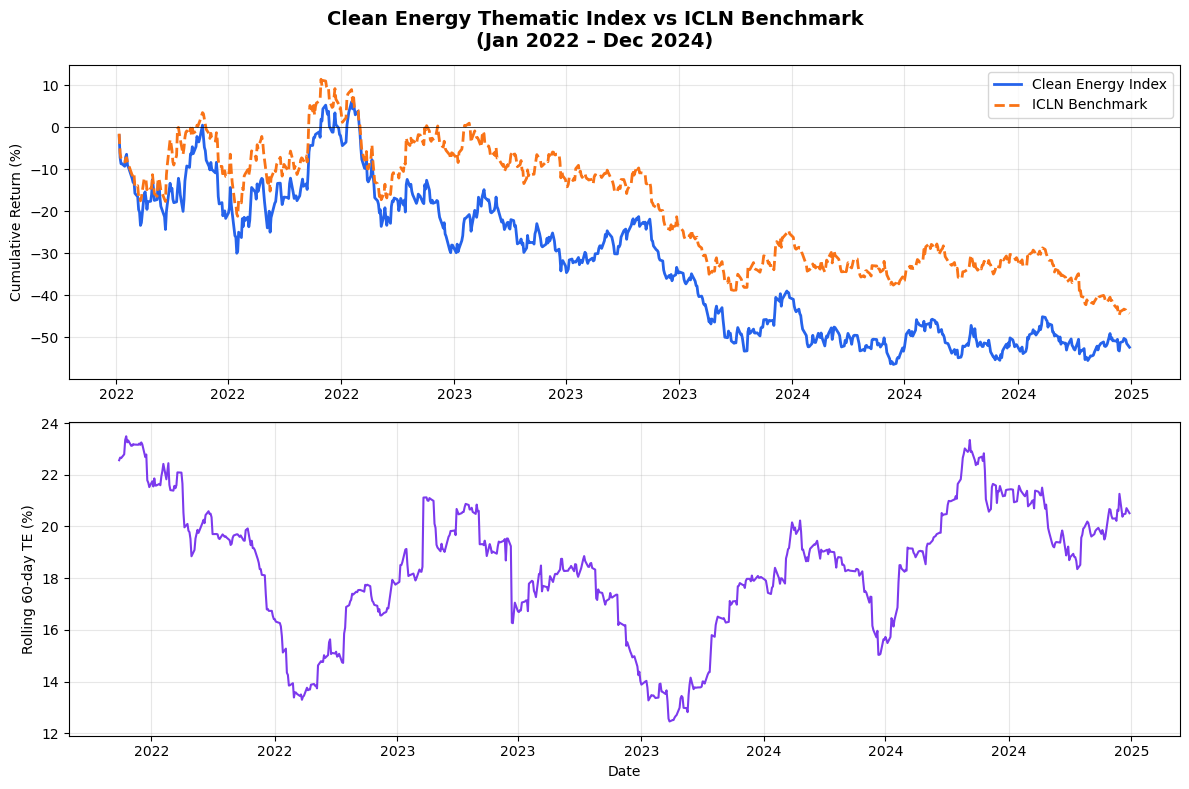

Chart saved.


In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Clean Energy Thematic Index vs ICLN Benchmark\n(Jan 2022 – Dec 2024)',
fontsize=14, fontweight='bold')

# Plot 1 — Cumulative performance
ax1.plot(index_cumulative.index, (index_cumulative-1)*100,
label='Clean Energy Index', color='#2563EB', linewidth=2)
ax1.plot(benchmark_cumulative.index, (benchmark_cumulative-1)*100,
label='ICLN Benchmark', color='#F97316', linewidth=2, linestyle='--')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2 — Rolling 60-day tracking error
rolling_te = active_return.rolling(60).std() * np.sqrt(252) * 100
ax2.plot(rolling_te.index, rolling_te, color='#7C3AED', linewidth=1.5)
ax2.set_ylabel('Rolling 60-day TE (%)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('clean_energy_index_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [50]:
# Higher threshold version
eligible_v2 = df[df['relevance_score'] >= 20].copy()
eligible_v2 = eligible_v2[eligible_v2['market_cap'] > 0]
print("V2 constituents:")
print(eligible_v2[['ticker', 'name', 'relevance_score']])

V2 constituents:
   ticker                          name  relevance_score
0    ENPH          Enphase Energy, Inc.            21.74
2    SEDG  SolarEdge Technologies, Inc.            21.74
5     NEE          NextEra Energy, Inc.            21.74
7    CWEN         Clearway Energy, Inc.            30.43
14   TSLA                   Tesla, Inc.            21.74
18    ALB         Albemarle Corporation            21.74


In [52]:
# Apply capped weights to V2
eligible_v2['weight'] = eligible_v2['market_cap'] / eligible_v2['market_cap'].sum()
eligible_v2['weight_capped'] = apply_cap(eligible_v2['weight'].values)
eligible_v2['weight_capped'] = eligible_v2['weight_capped'] / eligible_v2['weight_capped'].sum()

# Get price data
prices_v2 = yf.download(eligible_v2['ticker'].tolist() + ['ICLN'],
start='2022-01-01', end='2024-12-31',
auto_adjust=True)['Close']

returns_v2 = prices_v2.pct_change().dropna()
benchmark_returns = returns_v2['ICLN']

weights_v2 = dict(zip(eligible_v2['ticker'], eligible_v2['weight_capped']))
weights_series_v2 = pd.Series(weights_v2)

index_daily_v2 = returns_v2[eligible_v2['ticker'].tolist()].mul(weights_series_v2, axis=1).sum(axis=1)

# Metrics
index_cum_v2 = (1 + index_daily_v2).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()

active_v2 = index_daily_v2 - benchmark_returns
te_v2 = active_v2.std() * np.sqrt(252) * 100

ann_return_v2 = ((index_cum_v2.iloc[-1]) ** (252/len(index_daily_v2)) - 1) * 100
ann_bench = ((benchmark_cum.iloc[-1]) ** (252/len(benchmark_returns)) - 1) * 100

print("=" * 50)
print("V2 RESULTS — 20% Threshold")
print("=" * 50)
print(f"\nAnnualised Return:")
print(f" Index V2: {ann_return_v2:.2f}%")
print(f" Benchmark: {ann_bench:.2f}%")
print(f" Active: {ann_return_v2 - ann_bench:.2f}%")
print(f"\nTracking Error: {te_v2:.2f}%")
print(f"\nCumulative Return:")
print(f" Index V2: {(index_cum_v2.iloc[-1]-1)*100:.2f}%")
print(f" Benchmark: {(benchmark_cum.iloc[-1]-1)*100:.2f}%")

[*********************100%***********************]  7 of 7 completed

V2 RESULTS — 20% Threshold

Annualised Return:
 Index V2: -20.43%
 Benchmark: -17.82%
 Active: -2.61%

Tracking Error: 20.66%

Cumulative Return:
 Index V2: -49.40%
 Benchmark: -44.28%
